In [2]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import ast


In [3]:
dtype=torch.float32
device = 'cpu'

In [4]:
txt = open("N=10000-dt=2.5e-05-force=sin(2pi200t).txt").read().split('\t')
         # list of strings
f = np.array(txt, dtype=float)      # 30000 floats
t = torch.tensor(f[:10000], dtype =dtype)
u= torch.tensor(f[10000:20000],dtype =dtype)
x = torch.tensor(f[20000:30000],dtype =dtype)
v = torch.tensor(f[30000:],dtype =dtype)
print(len(f))
print(x)


40000
tensor([0.0000e+00, 0.0000e+00, 1.9632e-11,  ..., 5.7095e-08, 3.3124e-08,
        9.1173e-09])


In [5]:
#normalisation 


def zscore_normalize(x: torch.Tensor):
    """
    x: 1D tensor (N,) or (N,1)
    returns: x_norm, mean, std  with x_norm = (x-mean)/std
    """
    if x.dim() == 2 and x.size(1) == 1:
        x = x.view(-1)

    mean = x.mean()
    std = x.std(unbiased=False)  # population std; use unbiased=True if you prefer

    # avoid divide by zero
    std_safe = std.clone()
    if std_safe == 0:
        std_safe = torch.tensor(1.0, dtype=x.dtype, device=x.device)

    x_norm = (x - mean) / std_safe
    return x_norm, mean, std_safe


def zscore_denormalize(x_norm: torch.Tensor, mean: torch.Tensor, std: torch.Tensor):
    """
    Invert z-score: x = x_norm * std + mean
    """
    print('noir')
    print(x_norm)
    print('std')
    print(std)
    return x_norm * std + mean

In [6]:
x_train_norm, x_mean, x_std = zscore_normalize(x)
u_train_norm, u_mean, u_std = zscore_normalize(u)
v_train_norm, v_mean, v_std = zscore_normalize(v)

u_v = torch.stack([x[1:], v[1:]] , dim = 0)

Z = torch.stack([x[:-1], v[:-1], u[:-1]], dim=1)  # shape (T-1, 3)
print(Z[0,:].size())
# Targets Y_t = [x_t, v_t]
Y = torch.stack([x[1:], v[1:]], dim=1) 

# Closed-form LS: Y ≈ Z W, W shape (3,2)
Z_T = Z.T                                          # (3, T-1)
W_star = torch.linalg.lstsq(Z_T @ Z, Z_T @ Y).solution  # (3,2)
# Or, more simply (but less stable): W_star = torch.linalg.inv(Z_T @ Z) @ (Z_T @ Y)


torch.Size([3])


In [7]:
k = (2*np.pi*100)**2
m = 1
zeta, f_n = 0.015, 100.0      # 100 Hz
wn = 2 * np.pi * f_n
c = 2 * zeta * m * wn

# dt = t[1].item()
dt = 2.5e-5
N = len(t)
print(N)
print(dt)
N_list = np.arange(N)*dt
Nl = torch.tensor(N_list, dtype=dtype, device=device)
print(f'time increment: {dt} s, total time: {N*dt} s')
I2 = torch.tensor([[1,0],[0,1]], dtype=dtype).to(device)
A2 = torch.tensor([[0,1],[-k/m,-c/m]], dtype=dtype).to(device)
B2 = torch.tensor([[0],[1/m]], dtype=dtype).to(device)


Adisc = torch.linalg.inv(I2-dt*0.5*A2)@(I2+dt*0.5*A2)
Bdisc = torch.linalg.inv(I2-dt*0.5*A2)@(dt*B2)
x0_norm = torch.stack([x_train_norm[0], v_train_norm[0]])
x0 = torch.stack([torch.tensor(0),torch.tensor(0)])

10000
2.5e-05
time increment: 2.5e-05 s, total time: 0.25 s


In [8]:
class NARX(nn.Module):
    def __init__(self, A =None, B =None):
        super().__init__()
        self.hidden = nn.Linear(3, 2, bias=False)
      
        with torch.no_grad():
            if A != None:
                C = torch.cat((A,B), dim =1)
                self.hidden.weight[:] = C
              
            # self.out.weight[:] = torch.tensor([1,0])
            # self.v.weight[:] = torch.tensor([0,1])
            
    
    def forward(self, u, x0 = torch.tensor([0,0],dtype=torch.float32)):
        
        out = [x0]
        for i in range(1, len(u)):
            h_prev = out[i-1]                    # shape (2,)
            u_prev = u[i-1].view(1)              # shape (1,)
            inp = torch.cat((h_prev, u_prev), dim=0)  # shape (3,)
            xi = self.hidden(inp)                # shape (2,)
    
            out.append(xi)
        return torch.stack(out, dim=0)[:,0]
    

    
    def train_propegate(self, input):
        #step function 
        #return next states
        out = self.hidden(input)
        return out


tensor(1.4154e-16, grad_fn=<MseLossBackward0>)


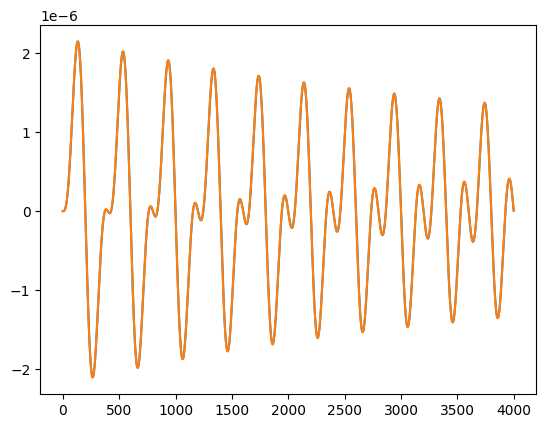

In [9]:
test = NARX(Adisc, Bdisc)

ypred = test(u)

print(nn.MSELoss()(x, ypred))
plt.plot(ypred.detach()[:4000])
plt.plot(x[:4000])


In [10]:
# training
def train_model(model, optimizer, x_train, v_train, f_train, epochs=10, exit = 1e-14):
    model.train()
     # CORRECT SHAPES: Z (N-1, 3), Y_target (N-1, 2)
    Z= torch.stack([x_train[:-1], v_train[:-1], f_train[:-1]], dim=1)  # (N-1, 3)
    Y_target = torch.stack([x_train[1:], v_train[1:]], dim=1) 
   
    
    for epoch in range(epochs):
        for t in range(9999):
            optimizer.zero_grad()
            input = Z[t]
            # print(input.size())
            pred = model.train_propegate(input)
            # print(pred.size())
            target = Y_target[t]

            
            loss = nn.MSELoss()(pred, target) 
            
              
            loss.backward()
            optimizer.step()
        x0 =torch.stack([x_train[0], v_train[0]])
        pred_full = model(f_train,x0 )
       
        
            
            

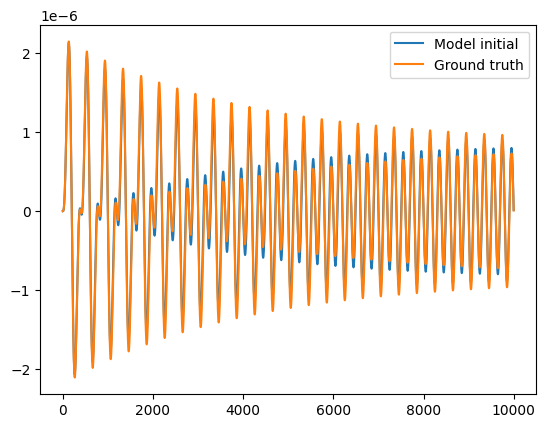

In [11]:

modelpert = NARX(Adisc*0.9999, Bdisc* 0.9999)
plt.plot(modelpert(u).detach(), label = 'Model initial ')
plt.plot(x, label = 'Ground truth')
plt.legend()

In [12]:
optimiserpert = torch.optim.Adam(modelpert.parameters(), lr=1e-7)
train_model(modelpert, optimiserpert, x_train_norm, v_train_norm, u_train_norm, epochs=5, exit = 1e-14)

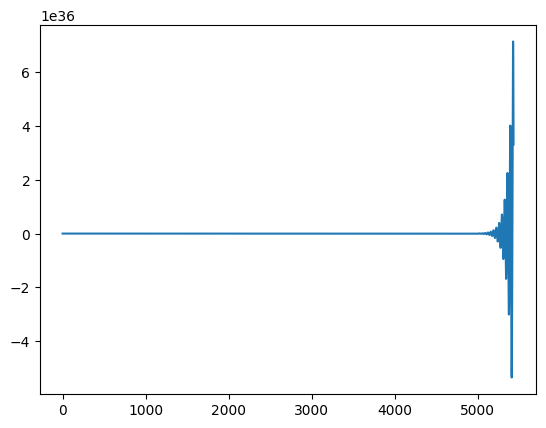

In [13]:

p = modelpert(u)

plt.plot(p.detach())